--- 1. Loading Prepared Data ---
Prepared features dataset loaded successfully.
Dataset dimensions: (160, 34)
Time period: 1985-07-01 00:00:00 to 2025-04-01 00:00:00

First 5 rows of the feature data:
            House_Index_diff1  CPI_diff1  Poverty_Rate_diff1  \
Date                                                           
1985-07-01               1.44       1.30                 0.0   
1985-10-01               0.42       0.65                 0.0   
1986-01-01               0.91       2.05                 0.0   
1986-04-01               1.79      -0.65                 0.0   
1986-07-01               1.98      -0.05                 0.0   

            Unemployment_Rate  Median_Household_Income_diff1  \
Date                                                           
1985-07-01                2.7                         1812.5   
1985-10-01                2.7                         1812.5   
1986-01-01                2.7                         1812.5   
1986-04-01                2.7 

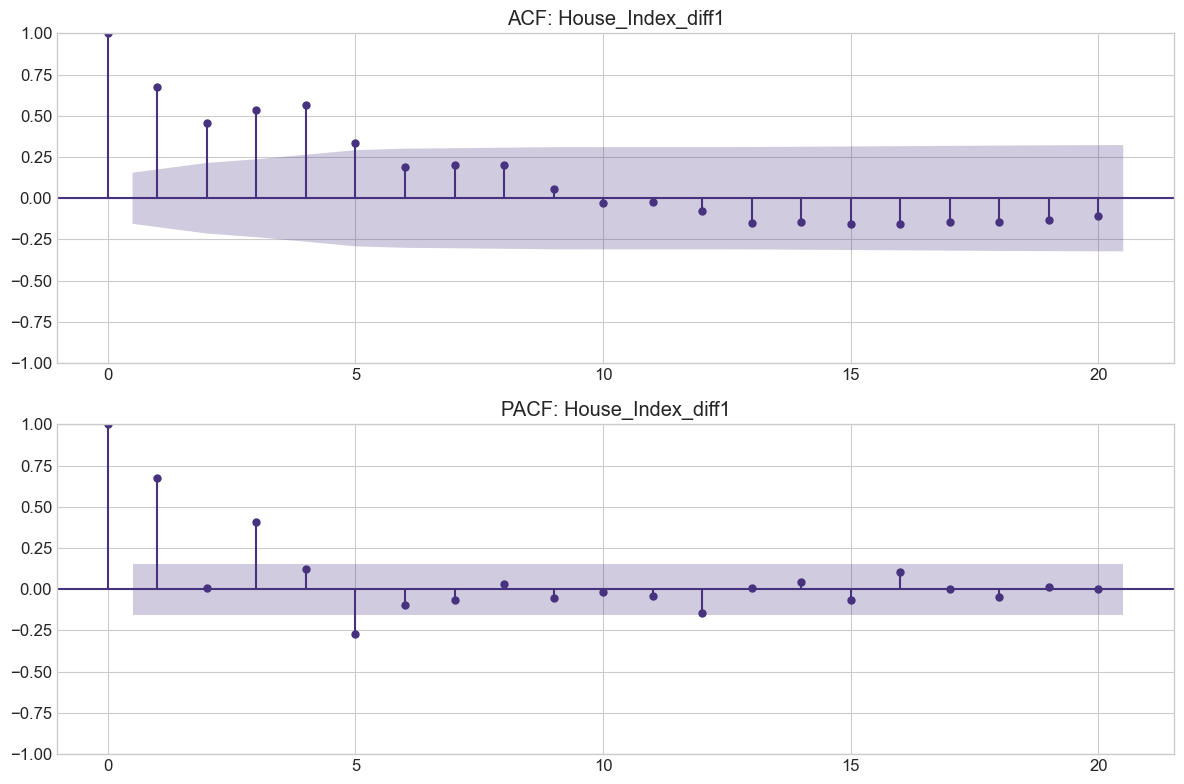

Tentative ARIMA order based on ACF/PACF inspection: p=1, d=0, q=1

Evaluating ARIMA(1,0,1) using TimeSeriesSplit:

Fold 1/5: Train size=30, Test size=26
Fold 1 - Test RMSE: 0.9847, MAE: 0.7153, MAPE: 237.29%

Fold 2/5: Train size=56, Test size=26
Fold 2 - Test RMSE: 6.8442, MAE: 5.2492, MAPE: 78.35%

Fold 3/5: Train size=82, Test size=26
Fold 3 - Test RMSE: 13.9280, MAE: 12.9962, MAPE: 975.28%

Fold 4/5: Train size=108, Test size=26
Fold 4 - Test RMSE: 2.2323, MAE: 1.7282, MAPE: 115.90%

Fold 5/5: Train size=134, Test size=26
Fold 5 - Test RMSE: 6.3597, MAE: 4.8155, MAPE: 50726095379535296.00%

ARIMA Cross-Validation Summary:
  Average RMSE: 6.0698 (+/- 4.5392)
  Average MAE:  5.1009 (+/- 4.3139)
  Average MAPE: 10145219075907340.00% (+/- 20290438151813976.00%)

Residual Analysis (based on last CV fold):


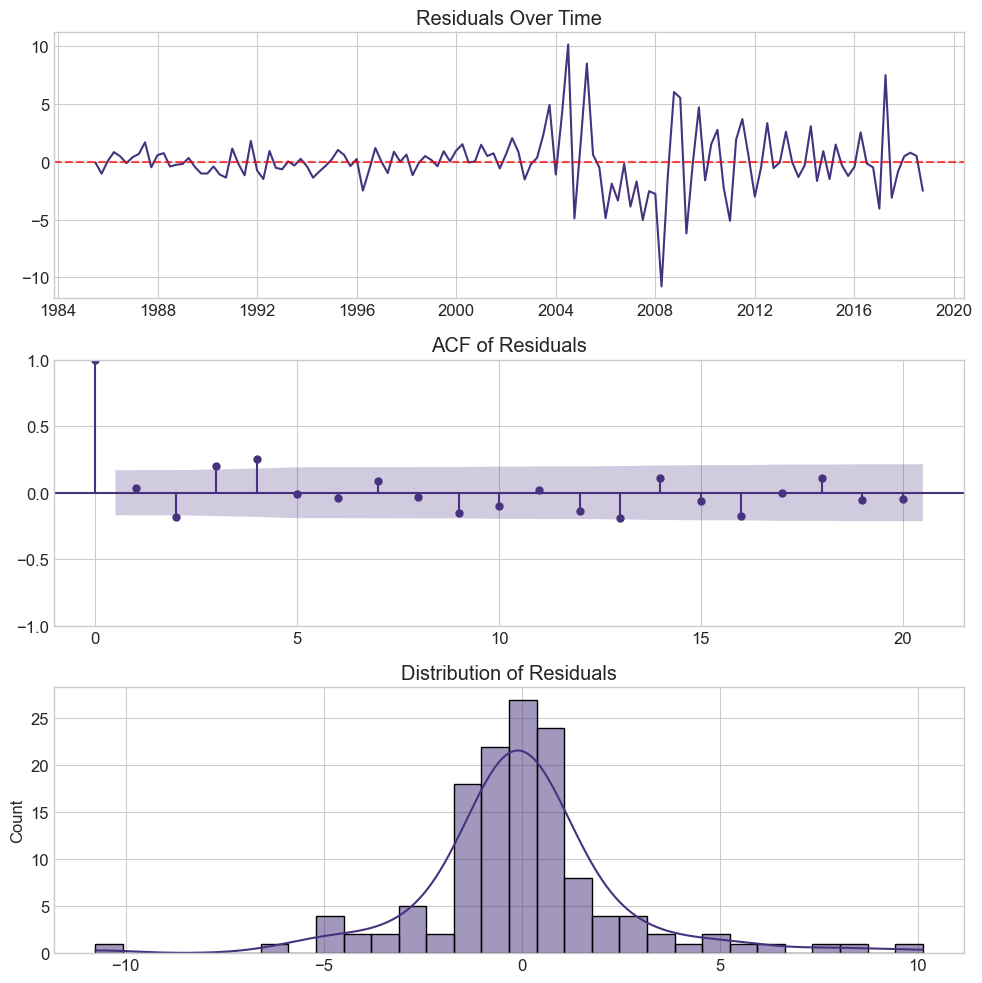


Ljung-Box Test on Residuals:
      lb_stat  lb_pvalue
10  25.383051   0.004665

--- 5. Model Building: VECM ---


NameError: name 'df' is not defined

In [ ]:
# -*- coding: utf-8 -*-
"""
DC Housing Market Forecasting - Modeling Phase

Goal: Build, evaluate, and compare time series models (ARIMA, VECM, ML)
      to forecast the DC housing market index based on the prepared data
      from the EDA phase. Use rigorous cross-validation and evaluation.
"""

# %% 0. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling Libraries
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX # For SARIMA if needed
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import VECM, select_order, select_coint_rank
from statsmodels.tsa.stattools import adfuller # Re-check stationarity if needed
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Scikit-learn for ML models, metrics, and CV
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# %% 1. Load Prepared Data
# =======================
print("--- 1. Loading Prepared Data ---")
try:
    # Load the features dataset created by the EDA script
    df_features = pd.read_csv('dc_housing_features_ready.csv', index_col='Date', parse_dates=True)
    print("Prepared features dataset loaded successfully.")
    print(f"Dataset dimensions: {df_features.shape}")
    print(f"Time period: {df_features.index.min()} to {df_features.index.max()}")
except FileNotFoundError:
    print("Error: dc_housing_features_ready.csv not found.")
    print("Please ensure the EDA script (dc_housing_eda_revised) was run successfully and the file exists.")
    exit()
except Exception as e:
    print(f"Error loading data: {e}")
    exit()

# Display first few rows and column names
print("\nFirst 5 rows of the feature data:")
print(df_features.head())
print("\nColumns available:")
print(df_features.columns.tolist())

# %% 2. Define Target and Features
# ===============================
print("\n--- 2. Defining Target and Features ---")

# Identify the target variable (based on EDA output)
TARGET_VARIABLE = 'House_Index_diff1' # Should be the stationary, differenced target

if TARGET_VARIABLE not in df_features.columns:
    print(f"Error: Target variable '{TARGET_VARIABLE}' not found in the loaded data.")
    # Attempt to find a suitable target if the name is slightly different
    possible_targets = [col for col in df_features.columns if 'House_Index' in col and 'diff1' in col]
    if possible_targets:
        TARGET_VARIABLE = possible_targets[0]
        print(f"Warning: Using '{TARGET_VARIABLE}' as the target variable.")
    else:
        print("Cannot identify target variable. Please check column names.")
        exit()

y = df_features[TARGET_VARIABLE]
X = df_features.drop(columns=[TARGET_VARIABLE])

print(f"Target variable (y): {TARGET_VARIABLE} (Shape: {y.shape})")
print(f"Predictor features (X): {X.shape[1]} columns (Shape: {X.shape})")

# --- Feature Selection (Placeholder) ---
# IMPORTANT: Feature selection is critical here due to the number of features.
# This should be done systematically within the modeling process.
# Options:
# 1. Manual Selection: Based on EDA (correlation, Granger, lead-lag), theory.
# 2. Automated: Lasso/Ridge coefficients, RFE, Tree-based importance.
# Start with a smaller, theoretically relevant subset for initial models.

# Example: Select features based on Granger causality or lead-lag analysis from EDA
# features_to_select = ['CPI_diff1', 'Interest_Rate_diff1_lag1', ...] # Populate based on EDA
# X_selected = X[features_to_select]
# print(f"Selected {len(features_to_select)} features for initial modeling.")
# For now, we proceed with all features (X), but selection is needed.


# %% 3. Setup Cross-Validation
# ===========================
print("\n--- 3. Setting up Cross-Validation ---")

# Use the same TimeSeriesSplit settings as defined in EDA
n_cv_splits = 5
tscv = TimeSeriesSplit(n_splits=n_cv_splits, test_size=None, gap=0) # Expanding window

print(f"Using TimeSeriesSplit with {n_cv_splits} splits.")

# Function to evaluate models using TSCV
def evaluate_model_cv(model, X_data, y_data, cv, scoring='neg_root_mean_squared_error'):
    """Evaluates a model using TimeSeriesSplit cross-validation."""
    scores = cross_val_score(model, X_data, y_data, cv=cv, scoring=scoring, n_jobs=-1)
    return scores

# %% 4. Model Building: ARIMA Baseline
# ===================================
print("\n--- 4. Model Building: ARIMA Baseline ---")
# ARIMA models are typically univariate, modeling the target variable's past values.
# Exogenous variables (predictors) can be added (ARIMAX).

# --- Step 4a: Determine ARIMA Order (p, d, q) ---
# Based on EDA (Section 9 of the EDA script):
# - Target variable is already differenced (d=0 in the context of y = House_Index_diff1).
# - Need to determine p (AR order) and q (MA order) from ACF/PACF plots of y.

print("Plotting ACF/PACF for the target variable to determine p and q:")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(y.dropna(), ax=ax1, lags=20, title=f'ACF: {TARGET_VARIABLE}')
ax1.grid(True)
plot_pacf(y.dropna(), ax=ax2, lags=20, method='ywm', title=f'PACF: {TARGET_VARIABLE}')
ax2.grid(True)
plt.tight_layout()
plt.show()

# Interpretation Guide:
# - PACF cuts off after lag p -> AR(p) model suggested.
# - ACF cuts off after lag q -> MA(q) model suggested.
# - Both ACF/PACF tail off -> ARMA(p, q) model suggested.

# Example: Based on visual inspection, let's assume p=1, q=1 for demonstration.
# Replace these with values inferred from your plots.
p_order = 1
d_order = 0 # Because y is already differenced
q_order = 1

print(f"Tentative ARIMA order based on ACF/PACF inspection: p={p_order}, d={d_order}, q={q_order}")

# --- Step 4b: Fit and Evaluate ARIMA model ---
# We will fit the model within the cross-validation loop for robust evaluation.

arima_rmse_scores = []
arima_mae_scores = []
arima_mape_scores = []
fold = 1

print(f"\nEvaluating ARIMA({p_order},{d_order},{q_order}) using TimeSeriesSplit:")
for train_index, test_index in tscv.split(y):
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    X_train, X_test = X.iloc[train_index], X.iloc[test_index] # Keep X for potential ARIMAX

    print(f"\nFold {fold}/{n_cv_splits}: Train size={len(y_train)}, Test size={len(y_test)}")

    try:
        # Fit ARIMA model on the training data
        # Note: For pure ARIMA, we only need y_train.
        # If using ARIMAX, add exog=X_train[selected_features]
        model_arima = ARIMA(y_train, order=(p_order, d_order, q_order))
        model_fit = model_arima.fit()
        # print(model_fit.summary()) # Optional: Print model summary for each fold

        # Forecast on the test set
        # start = len(y_train)
        # end = len(y_train) + len(y_test) - 1
        # Alternatively, use forecast method:
        forecast = model_fit.forecast(steps=len(y_test))
        # Ensure forecast index aligns with y_test index
        forecast.index = y_test.index

        # Evaluate forecast
        rmse = np.sqrt(mean_squared_error(y_test, forecast))
        mae = mean_absolute_error(y_test, forecast)
        mape = mean_absolute_percentage_error(y_test, forecast) * 100

        arima_rmse_scores.append(rmse)
        arima_mae_scores.append(mae)
        arima_mape_scores.append(mape)

        print(f"Fold {fold} - Test RMSE: {rmse:.4f}, MAE: {mae:.4f}, MAPE: {mape:.2f}%")

        # Optional: Plot forecast vs actual for this fold
        # plt.figure(figsize=(10, 5))
        # plt.plot(y_train.index, y_train, label='Train')
        # plt.plot(y_test.index, y_test, label='Actual Test', color='orange')
        # plt.plot(forecast.index, forecast, label='ARIMA Forecast', color='green', linestyle='--')
        # plt.title(f'ARIMA Forecast vs Actual - Fold {fold}')
        # plt.legend()
        # plt.show()

    except Exception as e:
        print(f"Fold {fold} - Error fitting/forecasting ARIMA: {e}")
        # Append NaN or handle error as appropriate
        arima_rmse_scores.append(np.nan)
        arima_mae_scores.append(np.nan)
        arima_mape_scores.append(np.nan)

    fold += 1

# --- Step 4c: Summarize ARIMA CV Results ---
print("\nARIMA Cross-Validation Summary:")
print(f"  Average RMSE: {np.nanmean(arima_rmse_scores):.4f} (+/- {np.nanstd(arima_rmse_scores):.4f})")
print(f"  Average MAE:  {np.nanmean(arima_mae_scores):.4f} (+/- {np.nanstd(arima_mae_scores):.4f})")
print(f"  Average MAPE: {np.nanmean(arima_mape_scores):.2f}% (+/- {np.nanstd(arima_mape_scores):.2f}%)")

# --- Step 4d: Residual Analysis (on the last fold or full data) ---
# Residuals should ideally be white noise (zero mean, constant variance, no autocorrelation)
if 'model_fit' in locals() and model_fit is not None: # Check if model was fit successfully
     print("\nResidual Analysis (based on last CV fold):")
     residuals = model_fit.resid
     
     fig, axes = plt.subplots(3, 1, figsize=(10, 10))
     # Residual Plot
     axes[0].plot(residuals.index, residuals)
     axes[0].axhline(0, color='red', linestyle='--', alpha=0.7)
     axes[0].set_title('Residuals Over Time')
     axes[0].grid(True)
     
     # ACF of Residuals
     plot_acf(residuals, ax=axes[1], lags=20, title='ACF of Residuals')
     axes[1].grid(True)
     
     # Histogram/Density Plot
     sns.histplot(residuals, kde=True, ax=axes[2])
     axes[2].set_title('Distribution of Residuals')
     axes[2].grid(True)
     
     plt.tight_layout()
     plt.show()
     
     # Ljung-Box test for autocorrelation in residuals
     try:
          lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True) # Test up to lag 10
          print("\nLjung-Box Test on Residuals:")
          print(lb_test)
          if lb_test['lb_pvalue'].iloc[0] < 0.05:
               print("Warning: Residuals may exhibit autocorrelation (Ljung-Box p < 0.05).")
          else:
               print("Residuals appear uncorrelated (Ljung-Box p >= 0.05).")
     except Exception as e:
          print(f"Could not perform Ljung-Box test: {e}")
else:
     print("\nSkipping residual analysis as the last model fit failed.")


# %% 5. Model Building: VECM
# =========================
print("\n--- 5. Model Building: VECM ---")
# VECM is recommended based on cointegration analysis (rank=1).
# VECM models the relationships between non-stationary variables in their LEVELS,
# while incorporating short-run dynamics using differenced terms and stationary exogenous variables.

# --- Step 5a: Prepare Data for VECM ---
# Need the original LEVEL data for the cointegrated variables identified in EDA.
# Need STATIONARY data for any exogenous predictors.

# Variables identified as cointegrated (from EDA Section 5)
# Example: multivariate_test_vars = ['House_Index', 'Median_Household_Income', 'Interest_Rate', 'Mortgage_Rate', 'CPI', 'GDP']
# Use the actual list from your EDA output if different.
vecm_level_vars = ['House_Index', 'Median_Household_Income', 'Interest_Rate', 'Mortgage_Rate', 'CPI', 'GDP']
df_levels = df[vecm_level_vars].loc[df_features.index] # Align level data with feature data index

# Exogenous variables (must be stationary)
# Select relevant stationary predictors from df_features (e.g., lags, rolling stats, dummies)
# IMPORTANT: Avoid including differenced versions of the level variables already in the VECM system.
potential_exog = X.copy()
cols_to_drop_from_exog = [col for col in potential_exog.columns if any(level_var in col for level_var in vecm_level_vars) and 'diff1' in col]
X_exog_vecm = potential_exog.drop(columns=cols_to_drop_from_exog, errors='ignore')

# Further selection needed for X_exog_vecm based on theory/EDA/feature selection methods
# Example: Keep only Unemployment_Rate (already stationary) and Recession dummy
vecm_exog_vars_selected = ['Unemployment_Rate', 'Recession'] # Example selection
X_exog_vecm_selected = X_exog_vecm[[col for col in vecm_exog_vars_selected if col in X_exog_vecm.columns]]

print(f"VECM Endogenous (Level) Variables: {df_levels.columns.tolist()}")
print(f"VECM Exogenous (Stationary) Variables Selected: {X_exog_vecm_selected.columns.tolist()}")

# --- Step 5b: Determine VECM Parameters ---
# Cointegration Rank (k_ar_diff): Determined in EDA (rank=1 in the example output)
coint_rank = 1 # Based on EDA output
# Lag Order (k_ar_diff): Number of lags for the VAR in differences. Needs selection.
# Use select_order on differenced data (or levels if appropriate for the function)
# data_diff_for_lag = df_levels.diff().dropna()
# lag_order_results = select_order(data_diff_for_lag, maxlags=8, deterministic='co') # 'co' for constant in cointegration relation
# vecm_lag_order = lag_order_results.aic # Or .bic, .hqic
# For simplicity, let's assume lag order p=2 (k_ar_diff = p-1 = 1) based on common practice/EDA hints
vecm_lag_order_k = 1
print(f"Using Cointegration Rank (r): {coint_rank}")
print(f"Using Lag Order (k_ar_diff): {vecm_lag_order_k}")

# --- Step 5c: Fit and Evaluate VECM ---
# Similar to ARIMA, evaluate within the CV loop.

vecm_rmse_scores = []
vecm_mae_scores = []
vecm_mape_scores = []
fold = 1

print(f"\nEvaluating VECM(k_ar_diff={vecm_lag_order_k}, coint_rank={coint_rank}) using TimeSeriesSplit:")
# Align exogenous data before splitting
if not X_exog_vecm_selected.empty:
    common_index = df_levels.index.intersection(X_exog_vecm_selected.index)
    df_levels_aligned = df_levels.loc[common_index]
    X_exog_vecm_aligned = X_exog_vecm_selected.loc[common_index]
else:
    df_levels_aligned = df_levels
    X_exog_vecm_aligned = None # No exogenous variables

for train_index, test_index in tscv.split(df_levels_aligned):
    levels_train = df_levels_aligned.iloc[train_index]
    levels_test = df_levels_aligned.iloc[test_index]
    
    exog_train = X_exog_vecm_aligned.iloc[train_index] if X_exog_vecm_aligned is not None else None
    exog_test = X_exog_vecm_aligned.iloc[test_index] if X_exog_vecm_aligned is not None else None

    print(f"\nFold {fold}/{n_cv_splits}: Train size={len(levels_train)}, Test size={len(levels_test)}")

    try:
        # Fit VECM model
        model_vecm = VECM(endog=levels_train, exog=exog_train,
                          k_ar_diff=vecm_lag_order_k,
                          coint_rank=coint_rank,
                          deterministic='ci') # 'ci'=constant in cointegration, 'co'=constant outside, 'nc'=none
        vecm_fit = model_vecm.fit()
        # print(vecm_fit.summary()) # Optional: Print summary

        # Forecast
        # Forecasting VECM requires providing future exogenous values if used
        forecast_steps = len(levels_test)
        exog_forecast = exog_test if exog_test is not None else None
        forecast = vecm_fit.predict(steps=forecast_steps, exog_pred=exog_forecast)
        
        # Extract forecast for the target variable (House_Index LEVEL)
        forecast_target_level = pd.Series(forecast[:, df_levels.columns.get_loc('House_Index')], index=levels_test.index)

        # Need to compare with the ACTUAL DIFFERENCED target variable (y_test)
        # To do this, difference the actual level test data and the forecast level data
        actual_target_diff = levels_test['House_Index'].diff().dropna() # Actual diff
        # Calculate the differenced forecast. Need the last value of the training level data.
        last_train_level = levels_train['House_Index'].iloc[-1]
        forecast_target_diff = forecast_target_level.diff()
        # Handle the first forecasted difference
        first_forecast_level = forecast_target_level.iloc[0]
        forecast_target_diff.iloc[0] = first_forecast_level - last_train_level

        # Align y_test with the differenced forecast/actuals
        common_diff_index = actual_target_diff.index.intersection(forecast_target_diff.index)
        y_test_aligned = y_test.loc[common_diff_index] # y_test is already differenced
        forecast_target_diff_aligned = forecast_target_diff.loc[common_diff_index]

        if len(y_test_aligned) > 0:
            # Evaluate forecast of the DIFFERENCE
            rmse = np.sqrt(mean_squared_error(y_test_aligned, forecast_target_diff_aligned))
            mae = mean_absolute_error(y_test_aligned, forecast_target_diff_aligned)
            mape = mean_absolute_percentage_error(y_test_aligned, forecast_target_diff_aligned) * 100

            vecm_rmse_scores.append(rmse)
            vecm_mae_scores.append(mae)
            vecm_mape_scores.append(mape)
            print(f"Fold {fold} - Test RMSE (on diff): {rmse:.4f}, MAE (on diff): {mae:.4f}, MAPE (on diff): {mape:.2f}%")
        else:
             print(f"Fold {fold} - Skipping evaluation due to alignment issues after differencing forecast.")
             vecm_rmse_scores.append(np.nan)
             vecm_mae_scores.append(np.nan)
             vecm_mape_scores.append(np.nan)

    except Exception as e:
        print(f"Fold {fold} - Error fitting/forecasting VECM: {e}")
        vecm_rmse_scores.append(np.nan)
        vecm_mae_scores.append(np.nan)
        vecm_mape_scores.append(np.nan)

    fold += 1

# --- Step 5d: Summarize VECM CV Results ---
print("\nVECM Cross-Validation Summary (evaluated on target variable differences):")
print(f"  Average RMSE: {np.nanmean(vecm_rmse_scores):.4f} (+/- {np.nanstd(vecm_rmse_scores):.4f})")
print(f"  Average MAE:  {np.nanmean(vecm_mae_scores):.4f} (+/- {np.nanstd(vecm_mae_scores):.4f})")
print(f"  Average MAPE: {np.nanmean(vecm_mape_scores):.2f}% (+/- {np.nanstd(vecm_mape_scores):.2f}%)")

# --- Step 5e: Residual Analysis ---
# VECM residual analysis is more complex, involving checks on the system residuals.
# Can check residuals for individual equations.


# %% 6. Model Building: Machine Learning Models
# ============================================
print("\n--- 6. Model Building: Machine Learning Models ---")
# Using the engineered features `df_features`. Target is `y`. Predictors `X`.

# --- Step 6a: Feature Scaling (for applicable models) ---
# Scale features for models like Ridge, SVR. Tree models don't require it.
scaler = StandardScaler()
# Fit scaler ONLY on training data within the CV loop to prevent data leakage.

# --- Step 6b: Define ML Models ---
# Create pipelines to include scaling and feature selection if desired.
models = {
    "Ridge": Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))]),
    "RandomForest": Pipeline([('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))]),
    # Add other models like SVR, GradientBoostingRegressor etc.
    # "SVR": Pipeline([('scaler', StandardScaler()), ('svr', SVR(C=1.0, epsilon=0.1))]),
    # "GBM": Pipeline([('gbm', GradientBoostingRegressor(n_estimators=100, random_state=42))])
}

# --- Step 6c: Evaluate ML Models using CV ---
ml_results = {}
print("\nEvaluating Machine Learning Models using TimeSeriesSplit:")

for model_name, model_pipeline in models.items():
    print(f"\n--- Evaluating: {model_name} ---")
    rmse_scores = []
    mae_scores = []
    mape_scores = []
    fold = 1

    for train_index, test_index in tscv.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        print(f"Fold {fold}/{n_cv_splits}: Train size={len(X_train)}, Test size={len(X_test)}")

        try:
            # Fit model pipeline on training data
            # Scaling (if included) is fit only on X_train
            model_pipeline.fit(X_train, y_train)

            # Predict on test data
            y_pred = model_pipeline.predict(X_test)

            # Evaluate
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            mae = mean_absolute_error(y_test, y_pred)
            mape = mean_absolute_percentage_error(y_test, y_pred) * 100

            rmse_scores.append(rmse)
            mae_scores.append(mae)
            mape_scores.append(mape)
            print(f"Fold {fold} - Test RMSE: {rmse:.4f}, MAE: {mae:.4f}, MAPE: {mape:.2f}%")

        except Exception as e:
            print(f"Fold {fold} - Error fitting/predicting {model_name}: {e}")
            rmse_scores.append(np.nan)
            mae_scores.append(np.nan)
            mape_scores.append(np.nan)

        fold += 1

    # Store average results
    ml_results[model_name] = {
        'rmse_mean': np.nanmean(rmse_scores), 'rmse_std': np.nanstd(rmse_scores),
        'mae_mean': np.nanmean(mae_scores), 'mae_std': np.nanstd(mae_scores),
        'mape_mean': np.nanmean(mape_scores), 'mape_std': np.nanstd(mape_scores)
    }

    print(f"\n{model_name} CV Summary:")
    print(f"  Average RMSE: {ml_results[model_name]['rmse_mean']:.4f} (+/- {ml_results[model_name]['rmse_std']:.4f})")
    print(f"  Average MAE:  {ml_results[model_name]['mae_mean']:.4f} (+/- {ml_results[model_name]['mae_std']:.4f})")
    print(f"  Average MAPE: {ml_results[model_name]['mape_mean']:.2f}% (+/- {ml_results[model_name]['mape_std']:.2f}%)")


# %% 7. Model Comparison and Selection
# ===================================
print("\n--- 7. Model Comparison and Selection ---")

# Compile results from all models
comparison_data = []

# ARIMA Results
comparison_data.append({
    'Model': f'ARIMA({p_order},{d_order},{q_order})',
    'RMSE_Mean': np.nanmean(arima_rmse_scores), 'RMSE_Std': np.nanstd(arima_rmse_scores),
    'MAE_Mean': np.nanmean(arima_mae_scores), 'MAE_Std': np.nanstd(arima_mae_scores),
    'MAPE_Mean': np.nanmean(arima_mape_scores), 'MAPE_Std': np.nanstd(arima_mape_scores)
})

# VECM Results (if run)
if 'vecm_rmse_scores' in locals() and vecm_rmse_scores:
     comparison_data.append({
          'Model': f'VECM(k={vecm_lag_order_k}, r={coint_rank})',
          'RMSE_Mean': np.nanmean(vecm_rmse_scores), 'RMSE_Std': np.nanstd(vecm_rmse_scores),
          'MAE_Mean': np.nanmean(vecm_mae_scores), 'MAE_Std': np.nanstd(vecm_mae_scores),
          'MAPE_Mean': np.nanmean(vecm_mape_scores), 'MAPE_Std': np.nanstd(vecm_mape_scores)
     })

# ML Results
for model_name, results in ml_results.items():
     comparison_data.append({
          'Model': model_name,
          'RMSE_Mean': results['rmse_mean'], 'RMSE_Std': results['rmse_std'],
          'MAE_Mean': results['mae_mean'], 'MAE_Std': results['mae_std'],
          'MAPE_Mean': results['mape_mean'], 'MAPE_Std': results['mape_std']
     })

# Create comparison DataFrame
df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.set_index('Model')
df_comparison = df_comparison.sort_values('RMSE_Mean') # Sort by best RMSE

print("\nModel Performance Comparison (Lower is better):")
print(df_comparison[['RMSE_Mean', 'MAE_Mean', 'MAPE_Mean']])

# Model Selection Considerations:
# - Performance Metrics: Choose model with best average performance on key metrics (e.g., RMSE, MAE).
# - Stability: Consider standard deviation of scores across folds. Lower std is more stable.
# - Complexity & Interpretability: Simpler models (ARIMA, Ridge) might be preferred if performance is similar.
# - Residuals: Ensure chosen model has well-behaved residuals.
# - Forecast Horizon: Some models might perform better at short vs. long horizons (requires further testing).

# Select the best model based on criteria
# best_model_name = df_comparison.index[0]
# print(f"\nSelected Best Model (based on lowest average RMSE): {best_model_name}")

# %% 8. Final Model Training and Forecasting
# =========================================
print("\n--- 8. Final Model Training and Forecasting ---")
# Once a best model type (and potentially features/hyperparameters) is selected:
# 1. Re-train the selected model on ALL available data (up to the forecast origin).
# 2. Generate forecasts for the desired future periods.
# 3. Remember to handle transformations (invert differencing, exponentiate logs if used)
#    to get forecasts in the original scale of House_Index. Apply bias correction if needed for log transforms.

print("Placeholder: Final model training and forecasting steps would go here.")
print("This involves selecting the best model from Section 7, potentially tuning it further,")
print("training it on the full dataset, and generating future predictions.")
print("Remember to handle retransformation carefully.")


print("\nModeling phase initial run complete.")